In [2]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.19726868686868676


/Users/joshua/myworkspace/dynrdpg/dynrdpg/datasets/synthetic.py:39: RuntimeWarning: invalid value encountered in divide
  X[t] = np.where(norms > 1, X[t] / norms, X[t])


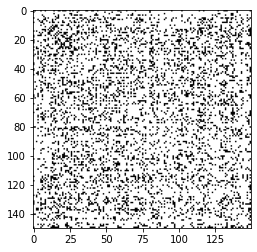

In [6]:
Y, X = simulate_network_rw(
    n_nodes=150, n_time_steps=11, density=0.2, sigma=0.05,
    random_state=23948)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.24951345454545404


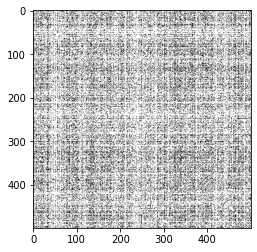

In [38]:
Y, X = simulate_network_gp(
    n_nodes=500, n_time_steps=11, density=0.25, random_state=23948)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

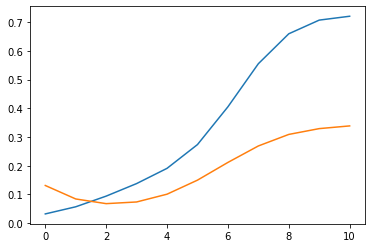

In [24]:
plt.plot(X[:, 0], '-')

In [54]:
rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y[:-1], n_burnin=1000, n_samples=1000)

100%|█████████████████████████████████████████████████████████████████| 2000/2000 [11:34<00:00,  2.88it/s]


0.7313095827340237


0.0028816641782262254

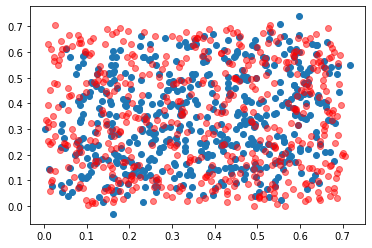

In [55]:
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics import roc_auc_score

t = 4
X_rdpg = rdpg.X_[t]
R, _ = orthogonal_procrustes(X_rdpg, X[t])
X_rdpg = X_rdpg @ R
plt.scatter(X_rdpg[:, 0], X_rdpg[:, 1])
plt.scatter(X[t][:, 0], X[t][:, 1], c='red', alpha=0.5)

subdiag = np.tril_indices_from(Y[t], k=-1)

print(roc_auc_score(Y[t][subdiag], rdpg.probas_[t]))
np.mean((X_rdpg - X[t]) ** 2)

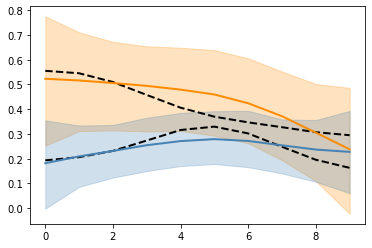

In [62]:
idx = 48


#print(np.sqrt(dase.sigma_[idx]))
X_est = rdpg.X_.copy()#np.mean(dase.samples_['X'], axis=0)
X_true = X.copy()
for t in range(len(Y)-1):
    R, _ = orthogonal_procrustes(X_true[t], X_est[t])
    X_true[t] = X_true[t] @ R
    
plt.plot(X_true[:-1, idx], '--', lw=2, color='k')

cis = np.quantile(rdpg.samples_['X'][:, :, idx], q=[0.025, 0.975], axis=0)
plt.plot(X_est[:, idx, 1], '-', color='darkorange', lw=2)
plt.plot(X_est[:, idx, 0], '-', color='steelblue', lw=2)
plt.fill_between(np.arange(len(Y)-1), cis[0, :, 1], cis[1, :, 1], color='darkorange', alpha=0.25)
plt.fill_between(np.arange(len(Y)-1), cis[0, :, 0], cis[1, :, 0], color='steelblue', alpha=0.25)

In [57]:
X_pred = rdpg.X_.copy()
for t in range(len(Y)-1):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
print(rdpg.auc_)
r_rdpg =np.mean((X_pred - X[:-1]) ** 2)
r_rdpg

0.7354022539594275


0.002823957839271135

In [58]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
from dynrdpg.dynrdpg import calculate_auc

proba_ase= []
X_ase = []
for t in range(len(Y)-1):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    ase = ASE(n_components=2)
    X_ase.append(ase.fit_transform(Y[t]))
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R
    proba_ase.append(np.clip((X_ase[t] @ X_ase[t].T)[subdiag], 0, 1))

X_ase = np.stack(X_ase)
proba_ase = np.stack(proba_ase)

print(calculate_auc(rdpg.y_vec_, proba_ase))
r_ase = np.mean((X_ase - X[:-1]) ** 2)# / np.mean(X ** 2))
r_ase

0.7423217561786244


0.005550929688722941

In [46]:
from graspologic.embed import MultipleASE as MASE

X_mase = MASE(n_components=2).fit_transform(Y[:-1])
np.mean((X_mase - X[:-1]) ** 2)

0.1463495118803768

In [47]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-1])
np.mean((X_omni - X[:-1]) ** 2)

0.11879741271033581

In [59]:
subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast()[subdiag]
y_true = Y[-1].toarray()[subdiag]

roc_auc_score(y_true, y_pred)

0.7267899890430842

In [49]:
subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = Y[-2].toarray()[subdiag]
y_true = Y[-1].toarray()[subdiag]

roc_auc_score(y_true, y_pred)

0.5686649077568968

In [50]:
from graspologic.embed import AdjacencySpectralEmbed as ASE

ase = ASE(n_components=2)
X_ase = ase.fit_transform(Y[-2])
y_pred = np.clip(X_ase @ X_ase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

roc_auc_score(y_true, y_pred)

0.7255491161834838

In [51]:
from graspologic.embed import MultipleASE as MASE

X_mase = MASE(n_components=2).fit_transform(Y[:-1])
y_pred = np.clip(X_mase @ X_mase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

roc_auc_score(y_true, y_pred)

0.5608175209897146

In [52]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-1])
y_pred = np.clip(X_omni[-1] @ X_omni[-1].T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

roc_auc_score(y_true, y_pred)

0.7018245606093143